In [9]:
!pip -q install -U ultralytics sahi pycocotools opencv-python tqdm pyyaml
from google.colab import drive
drive.mount('/content/drive')

DATASETS_DIR = "/content/drive/MyDrive/datasets"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, pathlib, json, subprocess, sys
pathlib.Path(DATASETS_DIR).mkdir(parents=True, exist_ok=True)
!yolo settings datasets_dir={DATASETS_DIR}

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Updated 'datasets_dir=/content/drive/MyDrive/datasets'
JSONDict("/root/.config/Ultralytics/settings.json"):
{
  "settings_version": "0.0.6",
  "datasets_dir": "/content/drive/MyDrive/datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb",
  "sync": true,
  "api_key": "",
  "openai_api_key": "",
  "clearml": true,
  "comet": true,
  "dvc": true,
  "hub": true,
  "mlflow": true,
  "neptune": true,
  "raytune": true,
  "tensorboard": false,
  "wandb": false,
  "vscode_msg": true,
  "openvino_msg": true
}
💡 Learn more about Ultralytics Settings at https://docs.ultralytics.com/quickstart/#ultralytics-s

In [3]:
!yolo detect val data=VisDrone.yaml model=yolov8n.pt imgsz=640 batch=1 device=0


Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'VisDrone.yaml' images not found, missing path '/content/drive/MyDrive/datasets/VisDrone/images/val'
Unzipping /content/drive/MyDrive/datasets/VisDrone/VisDrone2019-DET-val.zip to /content/drive/MyDrive/datasets/VisDrone/VisDrone2019-DET-val...: 100% ━━━━━━━━━━━━ 1099/1099 34.7files/s 31.6s
Unzipping /content/drive/MyDrive/datasets/VisDrone/VisDrone2019-DET-test-dev.zip to /content/drive/MyDrive/datasets/VisDrone/VisDrone2019-DET-test-dev...: 100% ━━━━━━━━━━━━ 3223/3223 40.7files/s 1:19
Unzipping /content/drive/MyDrive/datasets/VisDrone/VisDrone2019-DET-train.zip to /content/drive/MyDrive/datasets/VisDrone/VisDrone2019-DET-train...: 100% ━━━━━━━━━━━━ 12945/12945 74.8files/s 2:53
Converting train: ━━━━━━━━━━━━ 6471 62.6it/s 1:40
Converting val: ━━━━━━━━━━━━ 548 52.1it/s 9.9s
Converting test: ━━━━━━━━━━━━ 

In [19]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    task="detect",
    data="VisDrone.yaml",
    epochs=5,
    imgsz=960,
    batch=-1,
    device=0,
    amp=True,
    rect=True,
    patience=3,
    cos_lr=True,
    optimizer="AdamW",
    lr0=5e-4,
    weight_decay=0.01,
    warmup_epochs=2,
    warmup_momentum=0.8,
    warmup_bias_lr=0.05,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=0.8,
    close_mosaic=3,
    workers=2
)


Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=3, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.8, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=3, perspective=0.0, plots=True, pose=12.0, pretrained=Tru

In [18]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/models/runs/detect/train5/weights/best.pt")

print("Model loaded successfully:", model.model.yaml['nc'], "classes")


Model loaded successfully: 10 classes


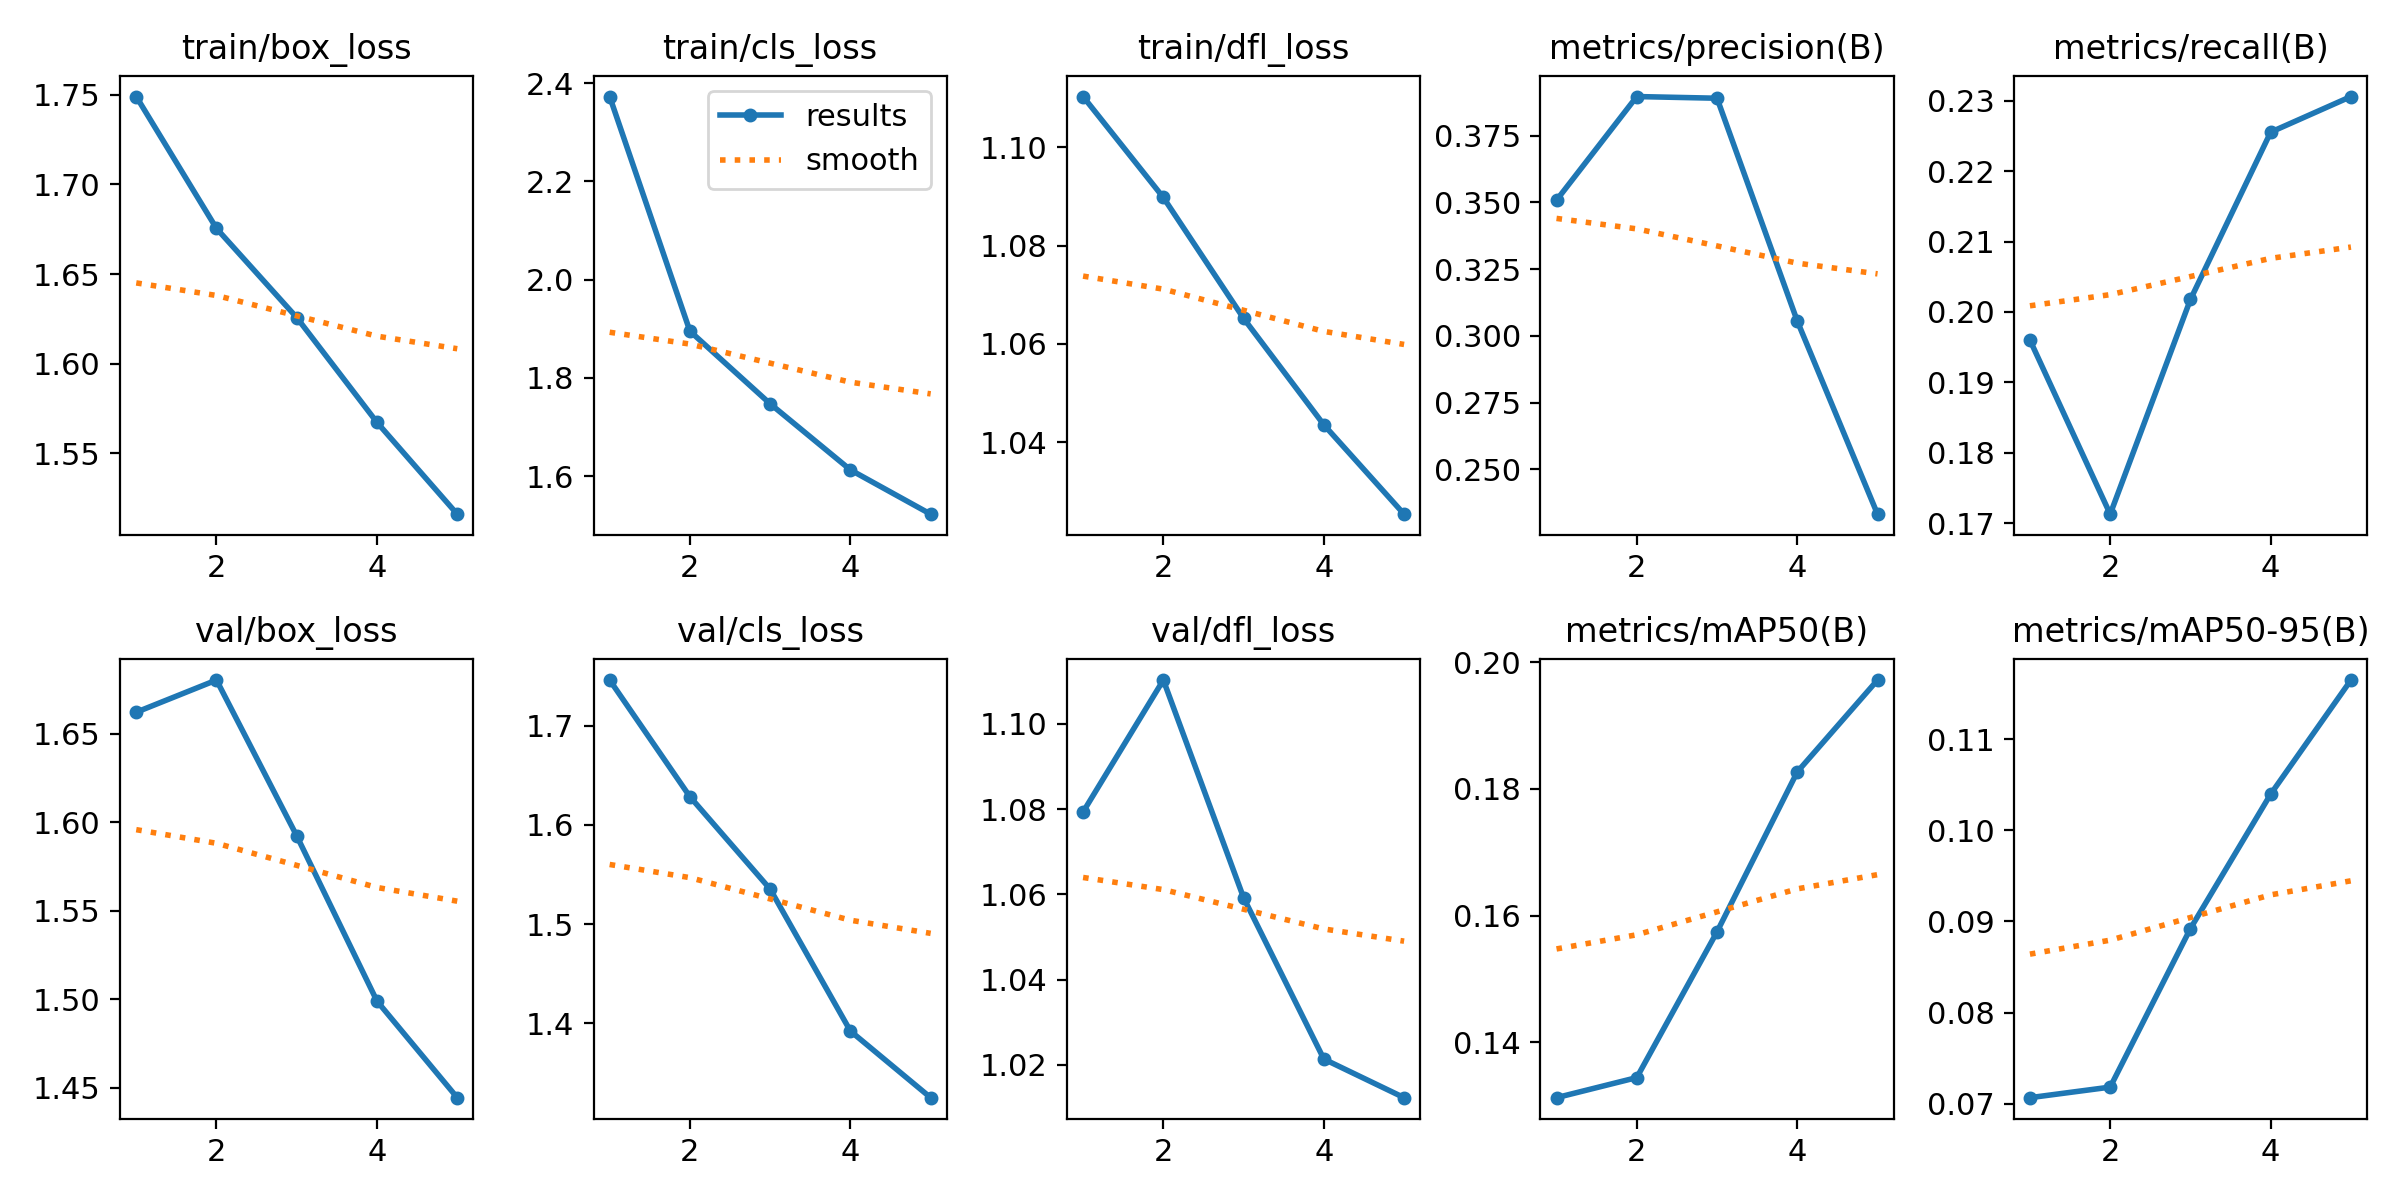

In [6]:
from IPython.display import Image, display
from pathlib import Path

RUN_DIR = Path("/content/drive/MyDrive/models/runs/detect/train5")

results_img = RUN_DIR / "results.png"
if results_img.exists():
    display(Image(filename=str(results_img), width=900))
else:
    print("No results.png found in", RUN_DIR)


In [20]:
val_results = model.val(data="VisDrone.yaml", imgsz=960, device=0)

print("\nPost-training Validation Results:")
print(f"mAP50:      {val_results.box.map50:.4f}")
print(f"mAP50-95:   {val_results.box.map:.4f}")


Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 52.2±20.7 MB/s, size: 147.6 KB)
val: Scanning /content/drive/MyDrive/datasets/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 759.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.2it/s 15.8s
                   all        548      38759      0.231      0.233      0.198      0.117
            pedestrian        520       8844      0.302      0.371      0.298      0.139
                people        482       5125      0.406      0.114      0.184     0.0704
               bicycle        364       1287     0.0236    0.00155     0.0235    0.00966
                   car        515      14064      0.465      0.756        0.7      0.479
                   van        421       1975      0.283      0.293       0.21      0.153
                 t

In [7]:
from pathlib import Path
DATASETS_DIR = Path("/content/drive/MyDrive/datasets/VisDrone")
VAL_IMG_DIR  = DATASETS_DIR / "images/val"
VAL_LBL_DIR  = DATASETS_DIR / "labels/val"
from pathlib import Path as _P
RUN_DIR = _P(RUN_DIR)
BEST_WEIGHTS = RUN_DIR / "weights/best.pt"
COCO_GT_JSON = RUN_DIR / "visdrone_val_coco_gt.json"
print(VAL_IMG_DIR.exists(), VAL_IMG_DIR)
print(VAL_LBL_DIR.exists(), VAL_LBL_DIR)
print(BEST_WEIGHTS.exists(), BEST_WEIGHTS)

True /content/drive/MyDrive/datasets/VisDrone/images/val
True /content/drive/MyDrive/datasets/VisDrone/labels/val
True /content/drive/MyDrive/models/runs/detect/train5/weights/best.pt


In [8]:
names = [
    "pedestrian", "person", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor"
]
categories = [{"id": i, "name": n, "supercategory": "object"} for i, n in enumerate(names)]

from pathlib import Path
Path(COCO_GT_JSON).parent.mkdir(parents=True, exist_ok=True)

import json, cv2
from pathlib import Path

img_files = sorted([p for p in Path(VAL_IMG_DIR).iterdir()
                    if p.suffix.lower() in {".jpg",".png",".jpeg"}])

images, annotations = [], []
ann_id = 1

for img_id, img_path in enumerate(img_files, start=1):
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    h, w = img.shape[:2]
    images.append({"id": img_id, "file_name": img_path.name, "height": h, "width": w})

    lbl_path = Path(VAL_LBL_DIR) / (img_path.stem + ".txt")
    if not lbl_path.exists():
        continue

    with open(lbl_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])

            x = (cx - bw/2.0) * w
            y = (cy - bh/2.0) * h
            ww = bw * w
            hh = bh * h

            x = max(0.0, min(x, w - 1))
            y = max(0.0, min(y, h - 1))
            ww = max(0.0, min(ww, w - x))
            hh = max(0.0, min(hh, h - y))

            annotations.append({
                "id": ann_id,
                "image_id": img_id,
                "category_id": cls,
                "bbox": [x, y, ww, hh],
                "area": float(ww * hh),
                "iscrowd": 0
            })
            ann_id += 1

coco = {"images": images, "annotations": annotations, "categories": categories}
with open(COCO_GT_JSON, "w") as f:
    json.dump(coco, f)
print("Wrote GT:", COCO_GT_JSON, f"(images={len(images)}, annots={len(annotations)})")


Wrote GT: /content/drive/MyDrive/models/runs/detect/train5/visdrone_val_coco_gt.json (images=548, annots=38759)


In [10]:
try:
    from sahi.models.yolov8 import Yolov8DetectionModel as DetModel
except ModuleNotFoundError:
    from sahi.models.ultralytics import UltralyticsDetectionModel as DetModel


In [11]:
from pathlib import Path
from sahi.predict import get_sliced_prediction
import json

out_dir = Path(RUN_DIR) / "sahi_val" / "run_sahi_manual"
out_dir.mkdir(parents=True, exist_ok=True)
pred_json = out_dir / "prediction.json"

file_to_id = {p.name: i+1 for i, p in enumerate(img_files)}

det = DetModel(
    model_path=str(BEST_WEIGHTS),
    confidence_threshold=0.001,
    device="cuda:0"
)

dets = []
for img_path in img_files:
    res = get_sliced_prediction(
        str(img_path),
        det,
        slice_height=640, slice_width=640,
        overlap_height_ratio=0.2, overlap_width_ratio=0.2,
        postprocess_type="NMS", postprocess_match_metric="IOU",
    )
    img_id = file_to_id[img_path.name]
    for ob in res.object_prediction_list:
        x1, y1, x2, y2 = ob.bbox.to_xyxy()
        dets.append({
            "image_id": img_id,
            "category_id": int(ob.category.id),
            "bbox": [float(x1), float(y1), float(x2-x1), float(y2-y1)],
            "score": float(ob.score.value),
        })

with open(pred_json, "w") as f:
    json.dump(dets, f)
print("Wrote preds:", pred_json, "count:", len(dets))


Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing predictio

2025-11-12 06:43:33,515 - sahi - WARNING - ignoring invalid prediction with bbox: [528.9071655273438, 540, 611.295654296875, 540] (ultralytics.py:242)
2025-11-12 06:43:33,970 - sahi - WARNING - ignoring invalid prediction with bbox: [209.0958709716797, 540, 290.306396484375, 540] (ultralytics.py:242)
2025-11-12 06:43:33,977 - sahi - WARNING - ignoring invalid prediction with bbox: [225.9362030029297, 540, 284.20965576171875, 540] (ultralytics.py:242)


Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.


2025-11-12 06:43:43,612 - sahi - WARNING - ignoring invalid prediction with bbox: [285.2557373046875, 540, 356.67437744140625, 540] (ultralytics.py:242)


Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 2 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing prediction on 6 slices.
Performing predictio

In [71]:
from pathlib import Path
print("RUN_DIR:", RUN_DIR)
print("BEST_WEIGHTS exists:", BEST_WEIGHTS.exists(), BEST_WEIGHTS)
print("VAL_IMG_DIR exists:", VAL_IMG_DIR.exists(), VAL_IMG_DIR)


RUN_DIR: /content/drive/MyDrive/models/runs/detect/train5
BEST_WEIGHTS exists: True /content/drive/MyDrive/models/runs/detect/train5/weights/best.pt
VAL_IMG_DIR exists: True /content/drive/MyDrive/datasets/VisDrone/images/val


In [12]:
from pathlib import Path
print("GT exists:", Path(COCO_GT_JSON).exists(), COCO_GT_JSON)


GT exists: True /content/drive/MyDrive/models/runs/detect/train5/visdrone_val_coco_gt.json


In [14]:
import json
from pathlib import Path

gt_path = Path(COCO_GT_JSON)
with open(gt_path, "r") as f:
    gt = json.load(f)

gt.setdefault("info", {"description": "VisDrone val", "version": "1.0"})
gt.setdefault("licenses", [])

with open(gt_path, "w") as f:
    json.dump(gt, f)

print("Patched GT:", gt_path)


Patched GT: /content/drive/MyDrive/models/runs/detect/train5/visdrone_val_coco_gt.json


In [15]:
import json
with open(pred_json, "r") as f:
    preds = json.load(f)

assert isinstance(preds, list), "predictions must be a LIST of detections"
need = {"image_id","category_id","bbox","score"}
missing = [i for i, det in enumerate(preds) if not need.issubset(det)]
print("Pred count:", len(preds), "| bad records:", len(missing))

gt_image_ids = {img["id"] for img in gt["images"]}
bad_img_ids = {det["image_id"] for det in preds if det["image_id"] not in gt_image_ids}
print("Unknown image_ids in preds:", sorted(list(bad_img_ids))[:10], "… total:", len(bad_img_ids))

bad_cats = {det["category_id"] for det in preds if not (0 <= det["category_id"] < 10)}
print("Out-of-range category_ids:", sorted(list(bad_cats)))


Pred count: 373643 | bad records: 0
Unknown image_ids in preds: [] … total: 0
Out-of-range category_ids: []


In [16]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

coco_gt = COCO(str(COCO_GT_JSON))

coco_gt.dataset.setdefault("info", {})
coco_gt.dataset.setdefault("licenses", [])
coco_gt.createIndex()

coco_dt = coco_gt.loadRes(str(pred_json))
E = COCOeval(coco_gt, coco_dt, iouType='bbox')
E.evaluate(); E.accumulate(); E.summarize()


loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
creating index...
index created!
Loading and preparing results...
DONE (t=3.40s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=54.57s).
Accumulating evaluation results...
DONE (t=2.30s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.210
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.111
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.074
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.171
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.224
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.045
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.157
 Average Recall     (AR) @[ IoU